# QSS 45 Final Project — Models



In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Find the cleaned dataset whether this notebook is run
# from the project root or from inside code/.
cwd = Path.cwd()

possible_data_paths = [
    cwd / "qss45_bronx_manhattan_clean.csv",
    cwd / "data" / "qss45_bronx_manhattan_clean.csv",
    cwd.parent / "data" / "qss45_bronx_manhattan_clean.csv"
]

DATA_PATH = next(
    (path for path in possible_data_paths if path.exists()),
    possible_data_paths[-1]
)

# Save outputs to output/ when possible.
if cwd.name == "code":
    OUTPUT_DIR = cwd.parent / "output"
else:
    OUTPUT_DIR = cwd / "output"

OUTPUT_DIR.mkdir(exist_ok=True)

print("Data path:", DATA_PATH)
print("Output folder:", OUTPUT_DIR)


Data path: /Users/ballasy/data/qss45_bronx_manhattan_clean.csv
Output folder: /Users/ballasy/output


## 1. Load cleaned data

In [4]:
data = pd.read_csv(DATA_PATH)

data["Bronx"] = (data["Borough"] == "Bronx").astype(int)

print(data.shape)
data.head()


(602, 13)


,NAME,MeanCommute,Transit,Income,Poverty,Unemployment,WorkAtHome,state,county,tract,Borough,GEOID,Bronx
0,"Census Tract 351, Bronx County, New York",45.2,43.2,71913.0,17.1,14.1,7.5,36,5,35100,Bronx,36005035100,1
1,"Census Tract 367, Bronx County, New York",40.3,61.2,23720.0,49.8,15.4,2.4,36,5,36700,Bronx,36005036700,1
2,"Census Tract 381, Bronx County, New York",45.4,65.0,25891.0,34.3,19.5,7.2,36,5,38100,Bronx,36005038100,1
3,"Census Tract 388, Bronx County, New York",42.6,45.3,51298.0,20.5,24.5,1.5,36,5,38800,Bronx,36005038800,1
4,"Census Tract 397, Bronx County, New York",29.1,36.3,21228.0,51.0,9.2,10.1,36,5,39700,Bronx,36005039700,1


## 2. Define predictors and outcome

In [6]:
features = [
    "Transit",
    "Income",
    "Poverty",
    "Unemployment",
    "WorkAtHome",
    "Bronx"
]

target = "MeanCommute"

X = data[features]
y = data[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (602, 6)
y shape: (602,)


## 3. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=45,
    stratify=data["Borough"]
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 481
Test rows: 121


## 4. Predictive OLS model

In [10]:
ols_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression())
])

ols_model.fit(X_train, y_train)

ols_predictions = ols_model.predict(X_test)

ols_r2 = r2_score(y_test, ols_predictions)
ols_rmse = mean_squared_error(y_test, ols_predictions) ** 0.5

print("OLS Test R²:", round(ols_r2, 3))
print("OLS Test RMSE:", round(ols_rmse, 3))


OLS Test R²: 0.733
OLS Test RMSE: 4.404


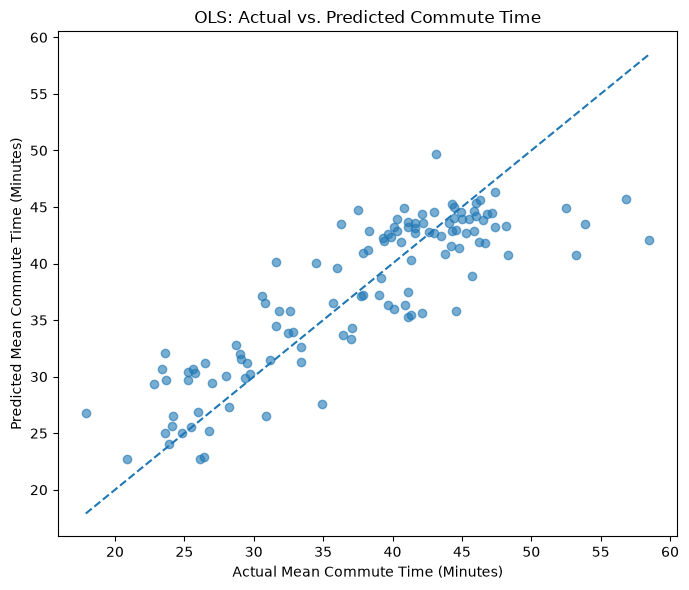

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    ols_predictions,
    alpha=0.6
)

minimum = min(y_test.min(), ols_predictions.min())
maximum = max(y_test.max(), ols_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Mean Commute Time (Minutes)")
plt.ylabel("Predicted Mean Commute Time (Minutes)")
plt.title("OLS: Actual vs. Predicted Commute Time")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ols_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 5. Model 1 — Borough only

In [13]:
X_bronx_only = sm.add_constant(data[["Bronx"]])

model1 = sm.OLS(
    y,
    X_bronx_only
).fit(cov_type="HC3")

model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MeanCommute   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     640.2
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.12e-96
Time:                        23:56:07   Log-Likelihood:                -1885.5
No. Observations:                 602   AIC:                             3775.
Df Residuals:                     600   BIC:                             3784.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.7989      0.389     79.131      0.000      30.036      31.562
Bronx         11.8335      0.468     25.303      0.000      10.917      12.750
==============================================================================
Omnibus:                        6.564   Durbin-Watson:                   1.348
Prob(Omnibus):                  0.038   Jarque-Bera (JB):                6.604
Skew:                           0.256   Prob(JB):                       0.0368
Kurtosis:                       2.988   Cond. No.                         2.73
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 6. Model 2 — Full controls

In [15]:
X_full = data[
    [
        "Bronx",
        "Transit",
        "Income",
        "Poverty",
        "Unemployment",
        "WorkAtHome"
    ]
]

X_full = sm.add_constant(X_full)

model2 = sm.OLS(
    y,
    X_full
).fit(cov_type="HC3")

model2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MeanCommute   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     276.0
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          2.97e-168
Time:                        23:56:07   Log-Likelihood:                -1725.0
No. Observations:                 602   AIC:                             3464.
Df Residuals:                     595   BIC:                             3495.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           26.3614      1.518     17.364      0.000      23.386      29.337
Bronx            9.1734      0.522     17.573      0.000       8.150      10.197
Transit          0.1742      0.015     11.287      0.000       0.144       0.204
Income        -5.44e-05   9.33e-06     -5.831      0.000   -7.27e-05   -3.61e-05
Poverty         -0.1405      0.023     -6.178      0.000      -0.185      -0.096
Unemployment     0.2415      0.047      5.176      0.000       0.150       0.333
WorkAtHome      -0.0779      0.063     -1.246      0.213      -0.201       0.045
==============================================================================
Omnibus:                       18.332   Durbin-Watson:                   1.546
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.161
Skew:                           0.422   Prob(JB):                     6.91e-05
Kurtosis:                       3.230   Cond. No.                     5.98e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 5.98e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 7. Compare Model 1 and Model 2

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Model 1: Borough only",
        "Model 2: Full controls"
    ],
    "Bronx coefficient": [
        model1.params["Bronx"],
        model2.params["Bronx"]
    ],
    "R_squared": [
        model1.rsquared,
        model2.rsquared
    ],
    "Adjusted_R_squared": [
        model1.rsquared_adj,
        model2.rsquared_adj
    ]
})

comparison.round(3)


,Model,Bronx coefficient,R_squared,Adjusted_R_squared
0,Model 1: Borough only,11.834,0.530,0.530
1,Model 2: Full controls,9.173,0.724,0.722


In [18]:
gap_reduction = (
    (model1.params["Bronx"] - model2.params["Bronx"])
    / model1.params["Bronx"]
) * 100

print(
    "Percent reduction in Bronx coefficient:",
    round(gap_reduction, 1),
    "%"
)


Percent reduction in Bronx coefficient: 22.5 %


## 8. Full-model coefficient table

In [20]:
model2_results = pd.DataFrame({
    "Variable": model2.params.index,
    "Coefficient": model2.params.values,
    "Std_Error": model2.bse.values,
    "P_Value": model2.pvalues.values,
    "CI_Low": model2.conf_int()[0].values,
    "CI_High": model2.conf_int()[1].values
})

model2_results.round(4)


,Variable,Coefficient,Std_Error,P_Value,CI_Low,CI_High
0,const,26.3614,1.5182,0.0000,23.3859,29.3369
1,Bronx,9.1734,0.5220,0.0000,8.1503,10.1965
2,Transit,0.1742,0.0154,0.0000,0.1439,0.2044
3,Income,-0.0001,0.0000,0.0000,-0.0001,-0.0000
4,Poverty,-0.1405,0.0227,0.0000,-0.1851,-0.0959
5,Unemployment,0.2415,0.0467,0.0000,0.1500,0.3329
6,WorkAtHome,-0.0779,0.0626,0.2129,-0.2005,0.0447


## 9. Full-model coefficient plot

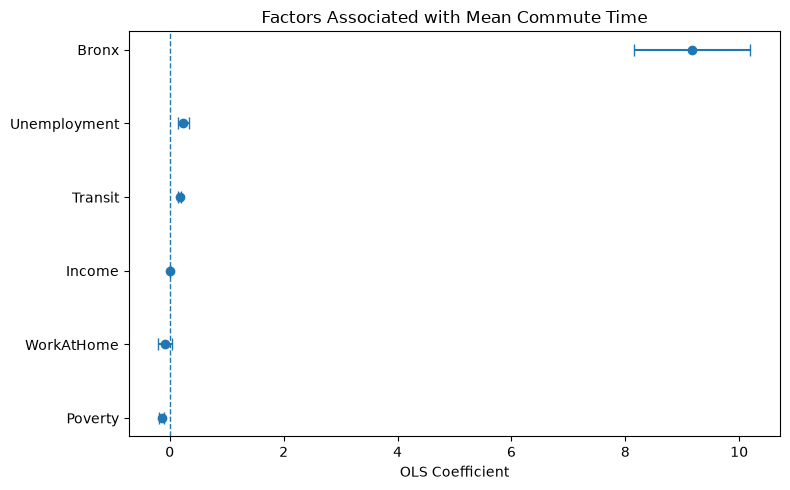

In [22]:
plot_data = (
    model2_results[
        model2_results["Variable"] != "const"
    ]
    .copy()
    .sort_values("Coefficient")
)

errors = np.vstack([
    plot_data["Coefficient"] - plot_data["CI_Low"],
    plot_data["CI_High"] - plot_data["Coefficient"]
])

plt.figure(figsize=(8, 5))

plt.errorbar(
    plot_data["Coefficient"],
    plot_data["Variable"],
    xerr=errors,
    fmt="o",
    capsize=4
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("OLS Coefficient")
plt.ylabel("")
plt.title("Factors Associated with Mean Commute Time")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "final_ols_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 10. Residual diagnostic

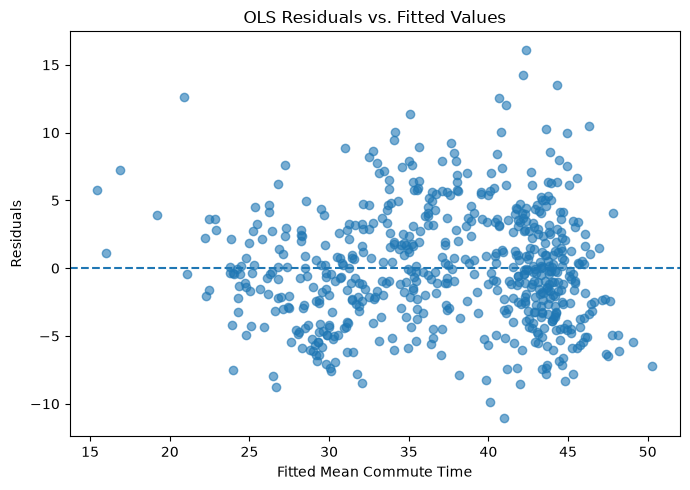

In [24]:
fitted = model2.fittedvalues
residuals = model2.resid

plt.figure(figsize=(7, 5))

plt.scatter(
    fitted,
    residuals,
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Mean Commute Time")
plt.ylabel("Residuals")
plt.title("OLS Residuals vs. Fitted Values")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ols_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Multicollinearity diagnostic

In [26]:
X_vif = data[
    [
        "Bronx",
        "Transit",
        "Income",
        "Poverty",
        "Unemployment",
        "WorkAtHome"
    ]
].copy()

X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table.round(2)


,Variable,VIF
0,const,1.00
1,Bronx,1.90
2,Transit,1.65
3,Income,3.92
4,Poverty,3.04
5,Unemployment,2.16
6,WorkAtHome,1.59


## 12. Bronx gap comparison figure

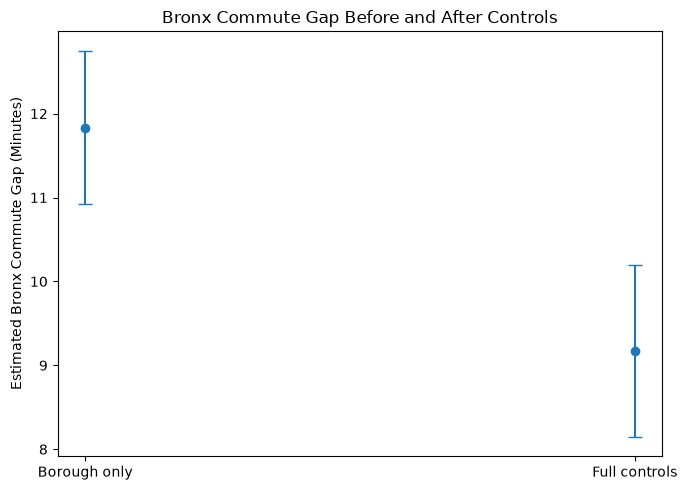

In [28]:
bronx_compare = pd.DataFrame({
    "Model": [
        "Borough only",
        "Full controls"
    ],
    "Coefficient": [
        model1.params["Bronx"],
        model2.params["Bronx"]
    ],
    "CI_Low": [
        model1.conf_int().loc["Bronx", 0],
        model2.conf_int().loc["Bronx", 0]
    ],
    "CI_High": [
        model1.conf_int().loc["Bronx", 1],
        model2.conf_int().loc["Bronx", 1]
    ]
})

errors = np.vstack([
    bronx_compare["Coefficient"] - bronx_compare["CI_Low"],
    bronx_compare["CI_High"] - bronx_compare["Coefficient"]
])

plt.figure(figsize=(7, 5))

plt.errorbar(
    bronx_compare["Model"],
    bronx_compare["Coefficient"],
    yerr=errors,
    fmt="o",
    capsize=5
)

plt.ylabel("Estimated Bronx Commute Gap (Minutes)")
plt.title("Bronx Commute Gap Before and After Controls")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "final_bronx_gap_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 13. Save model outputs

In [30]:
comparison.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)

vif_table.to_csv(
    OUTPUT_DIR / "vif_table.csv",
    index=False
)

model2_results.to_csv(
    OUTPUT_DIR / "full_ols_results.csv",
    index=False
)

print("Model outputs saved.")


Model outputs saved.


## 14. Final model summary

In [32]:
print("QSS 45 OLS Model Summary")
print("------------------------")

print("Raw Bronx commute gap:",
      round(model1.params["Bronx"], 2),
      "minutes")

print("Adjusted Bronx commute gap:",
      round(model2.params["Bronx"], 2),
      "minutes")

print("Model 1 R²:",
      round(model1.rsquared, 3))

print("Model 2 R²:",
      round(model2.rsquared, 3))

print("Predictive OLS Test R²:",
      round(ols_r2, 3))

print("Predictive OLS Test RMSE:",
      round(ols_rmse, 3),
      "minutes")

print("Percent reduction in Bronx coefficient:",
      round(gap_reduction, 1),
      "%")


QSS 45 OLS Model Summary
------------------------
Raw Bronx commute gap: 11.83 minutes
Adjusted Bronx commute gap: 9.17 minutes
Model 1 R²: 0.53
Model 2 R²: 0.724
Predictive OLS Test R²: 0.733
Predictive OLS Test RMSE: 4.404 minutes
Percent reduction in Bronx coefficient: 22.5 %
